# White Christmas Predictions and Philadelphia Weather

<img src= "Whitechristmas.png" width=500/>

1. How often has snow occurred versus not occurred on Christmas Day from 2005 to 2025?
2. What is the probability of a White Christmas (snowfall on December 25), based on historical weather data (2005-2025)?

**STEPS**
1. Filter rows by `day` column to only show December 25th
2. Filter the rows to find the years that had `snow`
3. Calculate the difference between days that had no snow versus the days that had snow to find how often snowfall occured
4. Calculate the probability of snowfall occuring on December 25th

### Setup

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Load the dataset

In [49]:
weather_df = pd.read_csv('data/philadelphia_weather_2005_to_2025.csv')
weather_df = weather_df.assign(date=pd.to_datetime(weather_df['date']))

#### Inspect the data

* We have looked at these data in a couple of previous notebooks
* Remind yourself of the columns
* Here the data goes from 2005 to 2025

In [50]:
weather_df.columns

Index(['day', 'year', 'high', 'low', 'rain', 'snow', 'date', 'day_num',
       'month_num', 'dow', 'dow_name', 'month'],
      dtype='str')

In [51]:
weather_df.head()

,day,year,high,low,rain,snow,date,day_num,month_num,dow,dow_name,month
0,January 1,2005,64,39,0.00,0.0,2005-01-01,1,1,5,Saturday,January
1,January 2,2005,47,33,0.01,0.0,2005-01-02,2,1,6,Sunday,January
2,January 3,2005,57,40,0.06,0.0,2005-01-03,3,1,0,Monday,January
3,January 4,2005,55,44,0.00,0.0,2005-01-04,4,1,1,Tuesday,January
4,January 5,2005,47,36,0.62,0.0,2005-01-05,5,1,2,Wednesday,January


In [52]:
weather_df['year'].value_counts()

year
2008    366
2020    366
2024    366
2016    366
2012    366
2009    365
2007    365
2006    365
2005    365
2013    365
2014    365
2011    365
2010    365
2017    365
2015    365
2019    365
2018    365
2021    365
2022    365
2023    365
2025    365
Name: count, dtype: int64

In [53]:
xmas_filter = weather_df['day'] == 'December 25'
weather_df[xmas_filter]

,day,year,high,low,rain,snow,date,day_num,month_num,dow,dow_name,month
358,December 25,2005,55,27,0.40,0.0,2005-12-25,25,12,6,Sunday,December
723,December 25,2006,49,33,0.69,0.0,2006-12-25,25,12,0,Monday,December
1088,December 25,2007,47,34,0.00,0.0,2007-12-25,25,12,1,Tuesday,December
1454,December 25,2008,60,30,0.04,0.0,2008-12-25,25,12,3,Thursday,December
1819,December 25,2009,41,28,0.26,0.0,2009-12-25,25,12,4,Friday,December
2184,December 25,2010,33,26,0.00,0.0,2010-12-25,25,12,5,Saturday,December
2549,December 25,2011,48,29,0.00,0.0,2011-12-25,25,12,6,Sunday,December
2915,December 25,2012,42,35,0.00,0.0,2012-12-25,25,12,1,Tuesday,December
3280,December 25,2013,32,21,0.00,0.0,2013-12-25,25,12,2,Wednesday,December
3645,December 25,2014,65,39,0.03,0.0,2014-12-25,25,12,3,Thursday,December


In [54]:
snow_on_xmas = weather_df[xmas_filter]['snow']>0
snow_on_xmas

358     False
723     False
1088    False
1454    False
1819    False
2184    False
2549    False
2915    False
3280    False
3645    False
4010    False
4376    False
4741    False
5106    False
5471    False
5837    False
6202    False
6567    False
6932    False
7298    False
7663    False
Name: snow, dtype: bool

# *OH NO!* #

Unfortunately, we can see from the data that shockingly there was no snowfall on any Christmas Day from 2005 to 2025. So instead of looking at snowfall on Christmas we can pivot and look at **Boxing Day** (December 26)!

<img src= "boxingday.png" width=300/>


But to answer the orignal questions – 
1. *Snow has occured 0 times out of 20 on every December 25th from 2005 to 2025.* 
2. *There is a 0% chance of snowfall on December 25th according to the historical data from 2005 to 2025*

---

# Snow on Boxing Day Predictions and Philadelphia Weather

The new questions we can asnwer are:

1. How many times did snowfall occur from 2005 to 2025 on Boxing Day (December 26)?
2. What was the probability of snow fall accoeding to the historical data on Boxing Day from 2005 to 2025?
3. `Bonus!` What was the probability of percipitation (rain and/or snow) on Boxing Day from 2005 to 2025?

**STEPS**

1. Filter rows by `day` column to only show December 26th
2. Filter the rows to find the years that had `snow`and count how many show data
3. Calculate the probability of snowfall and/or rain fall occuring on December 26th

In [40]:
boxing_day_filter = weather_df['day'] == 'December 26'
boxing_day = weather_df[boxing_day_filter]
boxing_day

,day,year,high,low,rain,snow,date,day_num,month_num,dow,dow_name,month
359,December 26,2005,47,41,0.02,0.0,2005-12-26,26,12,0,Monday,December
724,December 26,2006,53,44,0.02,0.0,2006-12-26,26,12,1,Tuesday,December
1089,December 26,2007,38,30,0.11,0.0,2007-12-26,26,12,2,Wednesday,December
1455,December 26,2008,44,29,0.00,0.0,2008-12-26,26,12,4,Friday,December
1820,December 26,2009,56,40,1.80,0.0,2009-12-26,26,12,5,Saturday,December
2185,December 26,2010,31,22,1.05,11.6,2010-12-26,26,12,6,Sunday,December
2550,December 26,2011,49,33,0.00,0.0,2011-12-26,26,12,0,Monday,December
2916,December 26,2012,45,32,1.18,0.0,2012-12-26,26,12,2,Wednesday,December
3281,December 26,2013,42,24,0.00,0.0,2013-12-26,26,12,3,Thursday,December
3646,December 26,2014,50,34,0.00,0.0,2014-12-26,26,12,4,Friday,December


In [41]:
boxing_day_snow = boxing_day.query('snow > 0')
boxing_day_snow

,day,year,high,low,rain,snow,date,day_num,month_num,dow,dow_name,month
2185,December 26,2010,31,22,1.05,11.6,2010-12-26,26,12,6,Sunday,December
7664,December 26,2025,33,27,0.32,0.3,2025-12-26,26,12,4,Friday,December


We have our first answer! 
- From the data we can see that from the years of 2005 to 2025 it snowed twice. Once in 2010 and once in 2025.

#### Fun Fact! 

- *Upon further research there was a great Boxing Day Blizzard that overtook the Northeast in 2010!*
- <img src="Dec26_27_2010_NJ_snow.webp" width=200/>
   
    - This picture is from Rutgers University Climate Lab



In [42]:
total_boxing_day_years = boxing_day.shape[0]
total_boxing_day_years

21

In [43]:
prob_of_snow = boxing_day_snow.shape[0]/total_boxing_day_years
prob_of_snow*100

9.523809523809524

We now have our second answer!
- The probability of seeing snow on boxing day was 9.52%

In [44]:
boxing_day_rain = boxing_day.query('rain > 0')
boxing_day_rain

,day,year,high,low,rain,snow,date,day_num,month_num,dow,dow_name,month
359,December 26,2005,47,41,0.02,0.0,2005-12-26,26,12,0,Monday,December
724,December 26,2006,53,44,0.02,0.0,2006-12-26,26,12,1,Tuesday,December
1089,December 26,2007,38,30,0.11,0.0,2007-12-26,26,12,2,Wednesday,December
1820,December 26,2009,56,40,1.80,0.0,2009-12-26,26,12,5,Saturday,December
2185,December 26,2010,31,22,1.05,11.6,2010-12-26,26,12,6,Sunday,December
2916,December 26,2012,45,32,1.18,0.0,2012-12-26,26,12,2,Wednesday,December
7664,December 26,2025,33,27,0.32,0.3,2025-12-26,26,12,4,Friday,December


In [45]:
percipitation = boxing_day_snow.shape[0] | boxing_day_rain.shape[0]
percipitation

7

In [46]:
prob_of_percipitation = percipitation/total_boxing_day_years
prob_of_percipitation*100

33.33333333333333

Finally for the last part of our analysis we know that... 
- The probability of seeing percipitation on boxing day from 2005 to 2025 was 33.3%

### Now let's visualize it!

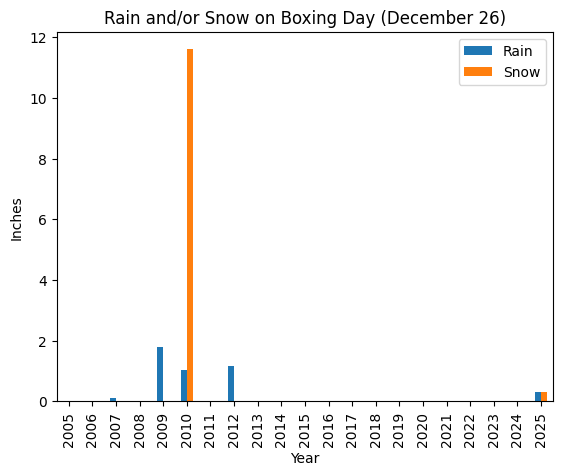

In [47]:
boxing_day.groupby("year")[["rain", "snow"]].sum().plot(kind="bar")

plt.xlabel("Year")
plt.ylabel("Inches")
plt.title("Rain and/or Snow on Boxing Day (December 26)")
plt.legend(["Rain", "Snow"])
plt.show()